In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from transformers import ViTModel, ViTImageProcessor
from datasets import load_dataset
from tqdm import tqdm
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, mean_squared_error
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [2]:
# Cell 3: Load Dataset & Define Transforms
print("Loading dataset...")

# 1. Load Dataset from Hugging Face (Mirror of CIFAKE)
# We use 'dragonintelligence/CIFAKE-image-dataset' which contains the full 120k images
dataset = load_dataset("dragonintelligence/CIFAKE-image-dataset")

# Check if dataset has splits, if not, create them (85% Train, 15% Test)
if 'test' not in dataset:
    print("Splitting dataset into Train/Test...")
    dataset = dataset['train'].train_test_split(test_size=0.15, seed=42)

print(f"Dataset Structure: {dataset}")

# 2. Define Feature Extractors
# ResNet Transform (Standard ImageNet Norms)
resnet_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# ViT Processor (Hugging Face standard processor)
vit_processor = ViTImageProcessor.from_pretrained('google/vit-base-patch16-224-in21k')

# 3. Custom Dataset Class to handle dual inputs
class DualInputDataset(Dataset):
    def __init__(self, hf_dataset, resnet_tf, vit_proc):
        self.dataset = hf_dataset
        self.resnet_tf = resnet_tf
        self.vit_proc = vit_proc

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        item = self.dataset[idx]
        image = item['image'].convert("RGB") # Ensure RGB
        label = item['label'] # 0 or 1

        # Prepare inputs
        resnet_img = self.resnet_tf(image)

        # ViT input: returns batch dimension, so we squeeze it
        vit_inputs = self.vit_proc(images=image, return_tensors="pt")
        vit_img = vit_inputs['pixel_values'].squeeze(0)

        return resnet_img, vit_img, torch.tensor(label, dtype=torch.float32)

# Create PyTorch Datasets
train_ds = DualInputDataset(dataset['train'], resnet_transform, vit_processor)
test_ds = DualInputDataset(dataset['test'], resnet_transform, vit_processor)

# DataLoaders
# Reduced batch size slightly to ensure safety on T4 GPU with dual models
BATCH_SIZE = 64
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print("Data loaded and processed successfully.")

Loading dataset...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/488 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/42.1M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/8.41M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/100000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/20000 [00:00<?, ? examples/s]

Dataset Structure: DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 100000
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 20000
    })
})


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

Data loaded and processed successfully.


In [3]:
class FeatureExtractor(nn.Module):
    def __init__(self):
        super(FeatureExtractor, self).__init__()

        # --- ResNet-50 (Local Texture) ---
        # Load pre-trained ResNet
        resnet = models.resnet50(pretrained=True)
        # Remove the final Fully Connected layer (fc)
        # We want the output of the pooling layer: [Batch, 2048, 1, 1] -> [Batch, 2048]
        self.resnet_backbone = nn.Sequential(*list(resnet.children())[:-1])

        # --- ViT-B/16 (Global Structure) ---
        self.vit_backbone = ViTModel.from_pretrained('google/vit-base-patch16-224-in21k')

    def forward(self, resnet_img, vit_img):
        # 1. ResNet Features
        r_feat = self.resnet_backbone(resnet_img)
        r_feat = r_feat.view(r_feat.size(0), -1) # Flatten: [Batch, 2048]

        # 2. ViT Features
        # ViT returns an object. pooler_output is [Batch, 768] (CLS token)
        v_out = self.vit_backbone(pixel_values=vit_img)
        v_feat = v_out.pooler_output

        # 3. Feature Fusion (Concatenation)
        # Final shape: [Batch, 2048 + 768] = [Batch, 2816]
        fused_features = torch.cat((r_feat, v_feat), dim=1)

        return fused_features

# Initialize and move to GPU
extractor = FeatureExtractor().to(device)
extractor.eval() # Set to eval mode for extraction
print("Feature Extractor Initialized.")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 122MB/s]


config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Feature Extractor Initialized.


In [4]:
def extract_all_features(loader, model, device):
    features_list = []
    labels_list = []

    print("Extracting features...")
    with torch.no_grad():
        for r_img, v_img, labels in tqdm(loader):
            r_img, v_img = r_img.to(device), v_img.to(device)

            # Get fused features
            fused = model(r_img, v_img)

            features_list.append(fused.cpu().numpy())
            labels_list.append(labels.numpy())

    X = np.concatenate(features_list, axis=0)
    y = np.concatenate(labels_list, axis=0)
    return X, y

# Extract Training Data
X_train, y_train = extract_all_features(train_loader, extractor, device)

# Extract Test Data
X_test, y_test = extract_all_features(test_loader, extractor, device)

print(f"\nFeature Extraction Complete.")
print(f"Train Shape: {X_train.shape}") # Should be (N, 2816)
print(f"Test Shape: {X_test.shape}")

Extracting features...


100%|██████████| 1563/1563 [23:18<00:00,  1.12it/s]


Extracting features...


100%|██████████| 313/313 [04:40<00:00,  1.12it/s]



Feature Extraction Complete.
Train Shape: (100000, 2816)
Test Shape: (20000, 2816)


Training MLP...
Epoch 1/20 | Loss: 0.1788
Best model saved at epoch 1 with loss 0.1788
Epoch 2/20 | Loss: 0.1107
Best model saved at epoch 2 with loss 0.1107
Epoch 3/20 | Loss: 0.0940
Best model saved at epoch 3 with loss 0.0940
Epoch 4/20 | Loss: 0.0818
Best model saved at epoch 4 with loss 0.0818
Epoch 5/20 | Loss: 0.0727
Best model saved at epoch 5 with loss 0.0727
Epoch 6/20 | Loss: 0.0678
Best model saved at epoch 6 with loss 0.0678
Epoch 7/20 | Loss: 0.0603
Best model saved at epoch 7 with loss 0.0603
Epoch 8/20 | Loss: 0.0542
Best model saved at epoch 8 with loss 0.0542
Epoch 9/20 | Loss: 0.0507
Best model saved at epoch 9 with loss 0.0507
Epoch 10/20 | Loss: 0.0463
Best model saved at epoch 10 with loss 0.0463
Epoch 11/20 | Loss: 0.0436
Best model saved at epoch 11 with loss 0.0436
Epoch 12/20 | Loss: 0.0401
Best model saved at epoch 12 with loss 0.0401
Epoch 13/20 | Loss: 0.0365
Best model saved at epoch 13 with loss 0.0365
Epoch 14/20 | Loss: 0.0341
Best model saved at epoch 

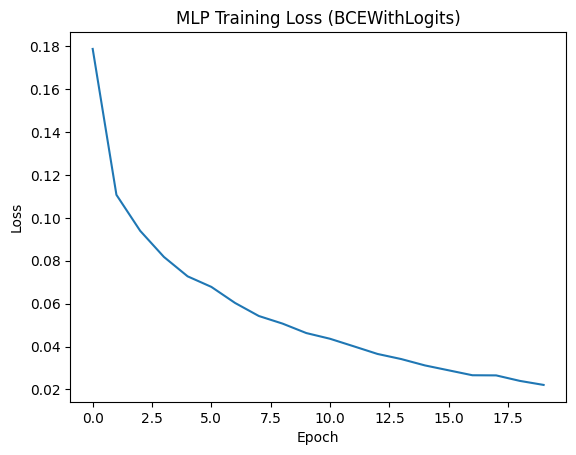

In [13]:
# 1. Define the MLP Classifier
class FusedClassifier(nn.Module):
    def __init__(self, input_dim):
        super(FusedClassifier, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 1) # Output 1 logit for Binary Classification
        )

    def forward(self, x):
        return self.layers(x)

# 2. Setup Training
input_dim = X_train.shape[1] # 2816
mlp_model = FusedClassifier(input_dim).to(device)

# Loss Functions
criterion = nn.BCEWithLogitsLoss() # Combines Sigmoid + BCE

# Optimizer
optimizer = optim.Adam(mlp_model.parameters(), lr=0.0001)

# Convert Numpy features back to PyTorch tensors for MLP training
train_features_tensor = torch.tensor(X_train, dtype=torch.float32)
train_labels_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
test_features_tensor = torch.tensor(X_test, dtype=torch.float32)
test_labels_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

# Create simplified loaders for the embeddings
train_emb_ds = torch.utils.data.TensorDataset(train_features_tensor, train_labels_tensor)
train_emb_loader = DataLoader(train_emb_ds, batch_size=64, shuffle=True)

# 3. Training Loop
epochs = 20
best_val_loss = float("inf")
train_losses = []

print("Training MLP...")
for epoch in range(epochs):
    mlp_model.train()
    running_loss = 0.0
    for inputs, targets in train_emb_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = mlp_model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_emb_loader)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f}")

    # --- Save best model ---
    if avg_loss < best_val_loss:
        best_val_loss = avg_loss
        torch.save(mlp_model.state_dict(), "best.pth")
        print(f"Best model saved at epoch {epoch+1} with loss {avg_loss:.4f}")

# Plot Loss
plt.plot(train_losses)
plt.title("MLP Training Loss (BCEWithLogits)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [7]:
!pip install -q xgboost

In [8]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",   # fast on Colab
    n_jobs=-1
)

In [12]:
xgb_model.fit(X_train, y_train)
print("XGBoost fitted ✅")

XGBoost fitted ✅


--- MLP (PyTorch) Results ---
Accuracy:  0.9779
Precision: 0.9738
Recall:    0.9823
F1-Score:  0.9780
MSE:       0.0179


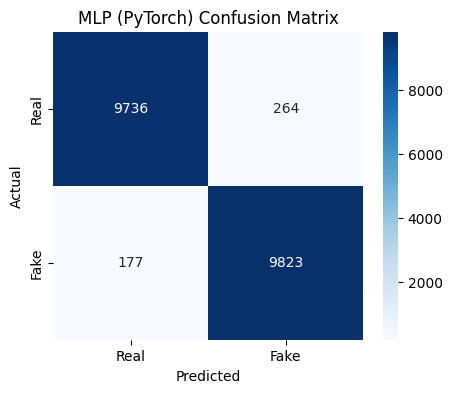

--- XGBoost Results ---
Accuracy:  0.9545
Precision: 0.9565
Recall:    0.9523
F1-Score:  0.9544
MSE:       0.0359


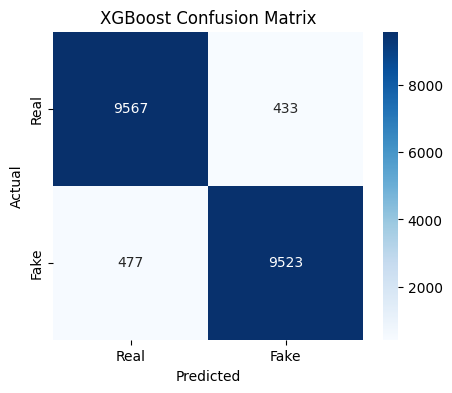

In [14]:
def evaluate_model(y_true, y_pred_prob, model_name):
    # Convert probabilities to binary predictions (Threshold 0.5)
    y_pred = (y_pred_prob >= 0.5).astype(int)

    # 1. Accuracy
    acc = accuracy_score(y_true, y_pred)
    # 2. Precision
    prec = precision_score(y_true, y_pred)
    # 3. Recall (Sensitivity)
    rec = recall_score(y_true, y_pred)
    # 4. F1-Score
    f1 = f1_score(y_true, y_pred)
    # 5. Mean Squared Error
    # MSE is calculated between binary label and probability
    mse = mean_squared_error(y_true, y_pred_prob)

    print(f"--- {model_name} Results ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"MSE:       {mse:.4f}")

    # 6. Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
    plt.title(f"{model_name} Confusion Matrix")
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

# --- Evaluate MLP ---
mlp_model.eval()
with torch.no_grad():
    mlp_logits = mlp_model(test_features_tensor.to(device))
    # Apply Sigmoid to get probabilities (0 to 1) from logits
    mlp_probs = torch.sigmoid(mlp_logits).cpu().numpy().flatten()

evaluate_model(y_test, mlp_probs, "MLP (PyTorch)")

# --- Evaluate XGBoost ---
# predict_proba returns [prob_class_0, prob_class_1]
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

evaluate_model(y_test, xgb_probs, "XGBoost")